# §4.3 "Residual Stream Representation Shifts" — воспроизведение эксперимента

Этот ноутбук воспроизводит **раздел 4.3** статьи (механистический анализ причин unfaithfulness
у VLM в задаче spot-the-difference) и рисунок **Figure 8** (плюс дополнительные детали из
**Appendix D.3**). Весь код собран и упрощён из `analysis/eval_cosine.py` и
`analysis/analyze_layer_changes.py` этого репозитория — здесь оставлено **только то, что
непосредственно нужно для двух анализов из §4.3**, без лишних метрик (ICR-score, JS-дивергенция
и т.п.), которые в §4.3 статьи не используются (они относятся к побочному коду в eval_cosine.py,
не упомянутому в тексте статьи).

## Что именно вычисляется

Пусть $x_l$ — вход в слой $l$ трансформера (residual stream). Проход через MHA- и
FFN-под-слои формализуется в статье как:

$$x_{l+1/2} = x_l + \mathrm{MHA}(\mathrm{LN}(x_l)) \qquad (1)$$
$$x_{l+1} = x_{l+1/2} + \mathrm{FFN}(\mathrm{LN}(x_{l+1/2})) \qquad (2)$$

и вводится косинусное сходство $\mathrm{CosSim}(u, v) := \dfrac{u \cdot v}{\lVert u \rVert \lVert v \rVert}$.

Эксперимент состоит из двух независимых частей:

- **Часть A — Semantic Drift in Binary Responses** (Figure 8a, Appendix D.3).
  Модели задают два "зеркальных" бинарных вопроса про одну и ту же пару изображений:
  *"Are the two pictures same?"* и *"Are the two pictures different?"*. Для каждого вопроса
  извлекаются послойные скрытые состояния $x_l^{same}$ и $x_l^{diff}$, и считается
  $\mathrm{CosSim}(x_l^{same}, x_l^{diff})$ на каждом слое. У *faithful* примеров (модель не
  противоречит себе) сходство остаётся высоким (>0.95) на всех слоях; у *unfaithful* примеров
  (модель дала логически противоречивые ответы) сходство заметно проседает в средних-глубоких
  слоях (в статье — до ~0.83).

- **Часть B — Sublayer Contribution Analysis** (Figure 8b).
  Для одного forward-прохода модели по изображению и вопросу считается
  $\mathrm{CosSim}(x_l, x_{l+1/2})$ (вклад MHA-под-слоя) и $\mathrm{CosSim}(x_{l+1/2}, x_{l+1})$
  (вклад FFN-под-слоя) на каждом слое, отдельно усредняя по подвыборкам faithful/unfaithful.
  Вывод статьи: MHA-переходы стабильны в обеих группах, а FFN-переходы у unfaithful примеров
  показывают резкое падение сходства — то есть именно FFN "уводит" внутреннее представление к
  галлюцинации, когда визуальных свидетельств недостаточно.

## Требования к входным данным

Оба анализа нужно запускать на уже **размеченных** примерах — то есть для каждого изображения
должно быть известно, был ли ответ модели *faithful* (`is_faithful=1`) или *unfaithful*
(`is_faithful=0`). Эта метка не выводится в этом ноутбуке: она получается на более раннем этапе
пайплайна (сравнение ответов модели на пару вопросов через `eval/eval_consistency_rate.py` /
`eval/eval_multi_diff_metrics.py`, см. README репозитория, формат "Model Output (JSON)"). Здесь
предполагается, что у вас уже есть JSONL с полями `image` и `is_faithful` — как на входе
`analysis/analyze_layer_changes.py`.

Если такого файла ещё нет, в конце секции загрузки данных есть **демо-режим**: он берёт пару
картинок из `data/examples/` и позволяет прогнать весь пайплайн технически (проверить, что код
работает и модель скачалась), но полученные на демо-данных кривые *не являются* воспроизведением
результатов статьи, т.к. `is_faithful` в демо-режиме не вычислен, а произвольно проставлен.

## 0. Установка зависимостей

Нужны: `torch`, `transformers>=4.45` (более старые версии не знают про `Qwen2VLForConditionalGeneration`),
`accelerate`, `qwen-vl-utils`, `matplotlib`, `numpy`, `tqdm`, `pillow`.

### Локально
Версии зафиксированы в `requirements.txt` репозитория. Модель `Qwen/Qwen2-VL-7B-Instruct`
весит ~15 ГБ и требует GPU (в статье — CUDA + bf16); на CPU код тоже отработает, но крайне медленно.

### На Kaggle
1. В настройках ноутбука (правая панель) включите **Accelerator → GPU T4 x2** (или P100) и
   **Internet → On** (нужен для `pip install` и скачивания весов модели с Hugging Face).
2. Kaggle-образ уже содержит `torch`+CUDA, но `transformers` там обычно старее, чем нужно, а
   `qwen-vl-utils` вообще не установлен — их нужно доустановить (следующая ячейка это делает
   автоматически, если обнаружено окружение Kaggle).
3. GPU на Kaggle (T4/P100) **не поддерживают bf16** нативно (это Turing/Pascal, не Ampere) — ниже
   в конфиге dtype подбирается автоматически (`bfloat16` только если GPU это поддерживает, иначе
   `float16`), вручную ничего менять не нужно.
4. Картинки и/или JSONL с метками `is_faithful` на Kaggle сами по себе недоступны — подключите их
   как **Add Input → Dataset** (например, загрузив папку `data/` этого репозитория как свой
   приватный датасет) и укажите путь к нему в конфиге ниже (`KAGGLE_DATASET_DIR`).

In [1]:
import os

IS_KAGGLE = os.path.exists("/kaggle/working")

if IS_KAGGLE:
    # Kaggle-образ уже содержит torch/CUDA -- доустанавливаем только то, чего не хватает:
    # свежий transformers (нужен Qwen2VLForConditionalGeneration), qwen-vl-utils, datasets
    # (для Jackson-Lv/SPD-Faith-Bench) и openai (нужен только если задан OPENAI_API_KEY, см. §3.1).
    get_ipython().system('pip install -q -U "transformers>=4.45.0" "accelerate>=0.26.0" qwen-vl-utils datasets openai')
else:
    pass  # локально: pip install -r ../requirements.txt && pip install qwen-vl-utils datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 76.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.4/95.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.1/83.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.8/343.8 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 46.3 MB/s eta 0:00:0000:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 50.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 4.4 MB/s eta 0:00:00
ERROR: pip's dependency

## 1. Конфигурация

Все настраиваемые параметры эксперимента собраны в одном месте. Пути и dtype подбираются
автоматически в зависимости от окружения (`IS_KAGGLE`, определён в предыдущей ячейке) — вручную
обычно нужно поправить только `KAGGLE_DATASET_DIR` (имя вашего Kaggle-датасета с картинками).

In [2]:
import json
import torch
from PIL import Image

# --- модель, как в статье ---
MODEL_PATH = "Qwen/Qwen2-VL-7B-Instruct"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def pick_dtype(device: str) -> torch.dtype:
    """Picks bfloat16 only when the GPU actually supports it natively (Ampere+, compute
    capability >= 8.0), otherwise falls back to float16. This matters on Kaggle: T4
    (compute 7.5, Turing) and P100 (compute 6.0, Pascal) do not support bf16, so forcing
    it there either errors out or silently runs a slow emulated path. On CPU we fall back
    to float32, since half precision on CPU is generally unsupported/very slow.
    """
    if device != "cuda":
        return torch.float32
    major, _minor = torch.cuda.get_device_capability(0)
    return torch.bfloat16 if major >= 8 else torch.float16


DTYPE = pick_dtype(DEVICE)

# --- входные данные и пути вывода: локальный репозиторий vs Kaggle ---
if IS_KAGGLE:
    # Подключите через "Add Input -> Datasets" датасет с содержимым папки data/ этого
    # репозитория (как минимум data/examples/) и, в идеале, JSONL с реальными метками
    # is_faithful. Путь виден в панели Input справа -- поправьте имя ниже на своё.
    # Если такого датасета нет, ниже есть fallback на прямую загрузку картинок с
    # Hugging Face (Jackson-Lv/SPD-Faith-Bench) -- см. секцию 2.1.
    KAGGLE_DATASET_DIR = "/kaggle/input/spd-faith-bench"
    INPUT_JSONL = f"{KAGGLE_DATASET_DIR}/samples_with_faithfulness.jsonl"
    IMAGE_DIR = f"{KAGGLE_DATASET_DIR}/data/examples"
    RESULTS_DIR = "/kaggle/working/results"
else:
    INPUT_JSONL = "../data/samples_with_faithfulness.jsonl"
    IMAGE_DIR = "../data/examples"
    RESULTS_DIR = "../results"

RESULTS_PATH = os.path.join(RESULTS_DIR, "section_4_3_results.json")
MAX_SAMPLES = 50                        # в статье -- до 200 примеров на группу

# --- зеркальные бинарные вопросы (см. Figure 6 и §4.3 статьи) ---
QUESTION_SAME = "Are the two pictures same?"
QUESTION_DIFF = "Are the two pictures different?"

# --- генерация для Части A ---
MAX_NEW_TOKENS = 128

print(f"IS_KAGGLE = {IS_KAGGLE}")
print(f"device    = {DEVICE}")
print(f"dtype     = {DTYPE}")
if DEVICE == "cuda":
    for i in range(torch.cuda.device_count()):
        name = torch.cuda.get_device_name(i)
        mem_gb = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"  GPU {i}: {name} ({mem_gb:.1f} GB)")

IS_KAGGLE = True
device    = cuda
dtype     = torch.float16
  GPU 0: Tesla T4 (15.6 GB)
  GPU 1: Tesla T4 (15.6 GB)


## 2. Загрузка размеченных примеров

`load_labeled_samples` читает JSONL с уже вычисленными метками `is_faithful` и путями к
изображениям. Каждая строка ожидается в формате, документированном в README репозитория
("Model Output (JSON)"):

```json
{"image": "merged_images/100238_color.jpg", "is_faithful": 1}
```

Функция ничего не вычисляет сама — она **только фильтрует и валидирует** входные данные
(отбрасывает записи без изображения на диске или с `is_faithful` вне `{0, 1}`); это единственное,
что нужно сделать перед запуском анализа.

In [3]:
def load_labeled_samples(jsonl_path: str, image_dir: str, max_samples=None):
    """Loads and validates labeled samples for section 4.3.

    Each JSONL line must contain {"image": <path relative to image_dir>,
    "is_faithful": 0 | 1, ...}. The is_faithful label must already be computed upstream
    (see eval/eval_consistency_rate.py) -- this function only reads it.

    Returns a list of dicts {"image_path": <path>, "is_faithful": int}, dropping records
    whose image file is missing or whose label is not 0/1.
    """
    samples = []
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            record = json.loads(line)
            is_faithful = record.get("is_faithful", -1)
            if is_faithful not in (0, 1):
                continue  # -1 = unlabeled / non-binary sample, skip
            image_path = os.path.join(image_dir, record["image"])
            if not os.path.exists(image_path):
                continue
            samples.append({"image_path": image_path, "is_faithful": is_faithful})
            if max_samples is not None and len(samples) >= max_samples:
                break
    return samples


if os.path.exists(INPUT_JSONL):
    samples = load_labeled_samples(INPUT_JSONL, IMAGE_DIR, MAX_SAMPLES)
    print(f"Загружено {len(samples)} размеченных примеров из {INPUT_JSONL}")
else:
    print(f"[!] {INPUT_JSONL} не найден -- переходим в демо-режим (см. следующую ячейку).")
    samples = []

[!] /kaggle/input/spd-faith-bench/samples_with_faithfulness.jsonl не найден -- переходим в демо-режим (см. следующую ячейку).


### 2.1 Если готового JSONL ещё нет

Автоматическая разметка (генерация ответов моделью + оценка консистентности через
GPT-4o-mini, как в `eval/eval_consistency_rate.py`) требует уже загруженной модели, поэтому
она вынесена в **§3.1**, сразу после загрузки модели ниже.

In [4]:
if not samples:
    print(f"{INPUT_JSONL} не найден -- samples остаётся пустым здесь, "
          f"автоматическая разметка выполнится ниже, в §3.1 (после загрузки модели).")

/kaggle/input/spd-faith-bench/samples_with_faithfulness.jsonl не найден -- samples остаётся пустым здесь, автоматическая разметка выполнится ниже, в §3.1 (после загрузки модели).


## 3. Загрузка модели

`load_model_and_processor` — тонкая обёртка над `from_pretrained`, идентичная той, что
используется во всех скриптах `analysis/` этого репозитория (см. `utils/model_utils.py`).
Возвращает модель, процессор (токенайзер + препроцессор изображений) и число слоёв трансформера
(нужно и Части A, и Части B, чтобы знать размер послойных массивов).

In [5]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor


def load_model_and_processor(model_path: str, device: str, dtype: torch.dtype):
    """Loads Qwen2-VL and its processor. dtype is chosen upstream by pick_dtype() -- bf16
    on GPUs that support it (e.g. A100), float16 on older GPUs without native bf16
    (Kaggle's T4/P100), float32 on CPU.

    device_map="auto" lets accelerate place weights across available GPUs/CPU offload
    (on Kaggle's dual-T4 sessions this automatically splits the model across both GPUs);
    .eval() disables dropout so representations are deterministic.
    Returns (model, processor, num_layers).
    """
    model = Qwen2VLForConditionalGeneration.from_pretrained(
        model_path, torch_dtype=dtype, device_map="auto" if device == "cuda" else None,
    )
    model.eval()
    if device != "cuda":
        model.to(device)
    processor = AutoProcessor.from_pretrained(model_path)

    if hasattr(model.config, "text_config"):
        num_layers = model.config.text_config.num_hidden_layers
    else:
        num_layers = model.config.num_hidden_layers

    return model, processor, num_layers


model, processor, NUM_LAYERS = load_model_and_processor(MODEL_PATH, DEVICE, DTYPE)
print(f"Модель загружена: {MODEL_PATH}, слоёв: {NUM_LAYERS}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Модель загружена: Qwen/Qwen2-VL-7B-Instruct, слоёв: 28


In [8]:
from qwen_vl_utils import process_vision_info


def build_model_inputs(processor, image_path: str, question: str, device: str):
    """Builds the multimodal input (one image + a text question) in the format Qwen2-VL
    expects: applies the chat template, encodes the image via process_vision_info, and
    packs everything into tensors on the target device.

    Used by both Part A (generation) and Part B (single forward pass) -- this is the one
    place that builds the model input, so both analyses see exactly the same prompt format.
    """
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {"type": "text", "text": question},
        ],
    }]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text], images=image_inputs, videos=video_inputs,
        padding=True, return_tensors="pt",
    ).to(device)
    return inputs

## 3.1 Автоматическая разметка `is_faithful` (если готового JSONL нет)

Выполняется только если `samples` пуст после §2 (т.е. `INPUT_JSONL` не найден). Для каждого
примера из HF-датасета `Jackson-Lv/SPD-Faith-Bench`:

1. модель отвечает на `QUESTION_SAME` и `QUESTION_DIFF` про одну и ту же пару картинок;
2. ответы проверяются на логическую консистентность одним из двух способов:
   - **rule-based (по умолчанию, без API-ключа)** — из обоих ответов извлекается yes/no и
     сверяется (а) друг с другом (нельзя одновременно сказать "да, одинаковые" и "да,
     разные") и (б) с реальным `num_differences` из датасета;
   - **GPT-4o-mini (опционально)** — включается автоматически, если в окружении задан
     `OPENAI_API_KEY`; воспроизводит логику `eval/eval_consistency_rate.py` (судья сравнивает
     конкретные утверждения в двух ответах, а не только yes/no) и точнее, но требует платного
     доступа к OpenAI API.

Результат — `is_faithful` (1 = ответы консистентны, 0 = противоречат друг другу) и JSONL с
разметкой, сохранённый на будущее, чтобы не размечать повторно.

In [9]:
from tqdm.auto import tqdm


def generate_answer_text(model, processor, image_path: str, question: str, device: str,
                          max_new_tokens: int = 256) -> str:
    """Generates just the model's text answer to (image, question), without collecting
    hidden states -- fast path used only for building is_faithful labels, not for the
    §4.3 metrics themselves (those use generate_with_layer_hidden_states instead).
    """
    inputs = build_model_inputs(processor, image_path, question, device)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    gen_ids = output_ids[0][inputs["input_ids"].shape[1]:]
    return processor.batch_decode([gen_ids], skip_special_tokens=True)[0]


def extract_yes_no(text: str):
    """Parses a leading yes/no judgment out of a free-form answer. Returns True ("yes"),
    False ("no"), or None if the answer doesn't clearly start with either -- used by the
    no-API rule-based consistency check below.
    """
    t = text.strip().lower()
    if t.startswith(("yes", "yeah", "yep")):
        return True
    if t.startswith(("no", "nope")):
        return False
    return None


def rule_based_is_faithful(response_same: str, response_diff: str, num_differences: int):
    """No-API consistency check: is_faithful = 1 only if the yes/no in response_same and
    response_diff (a) don't contradict each other (can't both be "yes") AND (b) agree with
    the dataset's ground-truth num_differences. Returns 0/1, or None if either answer
    couldn't be parsed as yes/no (such samples are skipped upstream, not mislabeled).
    """
    same_ans = extract_yes_no(response_same)   # True = "yes, the pictures are the same"
    diff_ans = extract_yes_no(response_diff)   # True = "yes, the pictures are different"
    if same_ans is None or diff_ans is None:
        return None

    self_consistent = same_ans != diff_ans
    expected_same = (num_differences == 0)
    matches_ground_truth = (same_ans == expected_same) and (diff_ans != expected_same)

    return int(self_consistent and matches_ground_truth)


def format_ground_truth(differences) -> str:
    """Formats the dataset's ground-truth differences list into the text block the
    GPT-4o-mini judge expects (same format as eval/eval_consistency_rate.py)."""
    if not differences:
        return "No differences (images are identical)"
    lines = [f"Total differences: {len(differences)}\n"]
    for i, d in enumerate(differences, 1):
        lines.append(f"{i}. Type: {d.get('type', 'unknown')}, Object: {d.get('category', 'unknown')}")
    return "\n".join(lines)


GPT_JUDGE_PROMPT = """You are evaluating the CONSISTENCY of a vision-language model's response.
The model was asked TWO questions about the same pair of images:
- Question A: "Are the two pictures the same?"
- Question B: "Are the two pictures different?"

Ground truth: {ground_truth}
Response to Question A: {response_same}
Response to Question B: {response_different}

Ignore the Yes/No judgments themselves and compare only the SPECIFIC difference claims made
in each response. Reply with ONLY a JSON object: {{"overall_consistency_rate": <float 0..1>}}."""


def gpt4o_mini_is_faithful(client, image_path: str, ground_truth_text: str,
                            response_same: str, response_diff: str, threshold: float = 0.8):
    """Optional, more faithful reproduction of eval/eval_consistency_rate.py: sends the
    merged image + both answers to GPT-4o-mini and asks it to score claim-level consistency
    in [0, 1], then binarizes with `threshold`. Returns 0/1, or None on an API/parsing error
    (such samples are skipped upstream, not mislabeled). Only called when OPENAI_API_KEY is set.
    """
    import base64
    from io import BytesIO

    img = Image.open(image_path)
    img.thumbnail((1024, 1024))
    buf = BytesIO()
    img.save(buf, format="JPEG", quality=85)
    img_b64 = base64.b64encode(buf.getvalue()).decode("utf-8")

    prompt = GPT_JUDGE_PROMPT.format(
        ground_truth=ground_truth_text, response_same=response_same, response_different=response_diff,
    )
    try:
        resp = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": [
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img_b64}"}},
                {"type": "text", "text": prompt},
            ]}],
            max_tokens=300, temperature=0, timeout=60,
        )
        text = (resp.choices[0].message.content or "").strip()
        text = text.removeprefix("```json").removeprefix("```").removesuffix("```").strip()
        rate = float(json.loads(text)["overall_consistency_rate"])
        return int(rate >= threshold)
    except Exception as e:
        print(f"  [GPT-4o-mini judge error, skipping sample] {e}")
        return None

In [10]:
def auto_label_is_faithful(model, processor, device, hf_split="hard", max_samples=20,
                            gpt_threshold=0.8, output_jsonl=None, image_dir=None):
    """Builds an is_faithful-labeled sample list (and JSONL) straight from the raw HF
    dataset when you don't already have one. For each example: (1) merges image1/image2
    like the local data/examples layout, (2) asks the model QUESTION_SAME and
    QUESTION_DIFF, (3) checks consistency via GPT-4o-mini if OPENAI_API_KEY is set,
    otherwise via the no-API rule_based_is_faithful.

    This label is NOT part of §4.3 itself -- it is the upstream faithfulness ground truth
    that §4.3's mechanistic analysis is conditioned on (see the paper's consistency-rate
    evaluation). Returns (samples, image_dir), where samples is the same
    [{"image_path", "is_faithful"}, ...] format load_labeled_samples() produces.
    """
    from datasets import load_dataset

    use_gpt = bool(os.environ.get("OPENAI_API_KEY"))
    client = None
    if use_gpt:
        from openai import OpenAI
        client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
        print("Разметка через GPT-4o-mini (OPENAI_API_KEY найден).")
    else:
        print("OPENAI_API_KEY не найден -- разметка через rule-based проверку (без API).")

    ds = load_dataset("Jackson-Lv/SPD-Faith-Bench", split=hf_split, streaming=True)
    image_dir = image_dir or os.path.join(RESULTS_DIR, "hf_images")
    os.makedirs(image_dir, exist_ok=True)

    records = []
    for i, row in enumerate(tqdm(ds, total=max_samples, desc="Auto-labeling is_faithful")):
        if i >= max_samples:
            break

        img1, img2 = row["image1"].convert("RGB"), row["image2"].convert("RGB")
        merged = Image.new("RGB", (img1.width, img1.height + img2.height))
        merged.paste(img1, (0, 0))
        merged.paste(img2, (0, img1.height))
        image_path = os.path.join(image_dir, f"{row['image_id']}.jpg")
        merged.save(image_path)

        response_same = generate_answer_text(model, processor, image_path, QUESTION_SAME, device)
        response_diff = generate_answer_text(model, processor, image_path, QUESTION_DIFF, device)

        if use_gpt:
            is_faithful = gpt4o_mini_is_faithful(
                client, image_path, format_ground_truth(row["differences"]),
                response_same, response_diff, threshold=gpt_threshold,
            )
        else:
            is_faithful = rule_based_is_faithful(response_same, response_diff, row["num_differences"])

        if is_faithful is None:
            continue  # ответ не удалось однозначно разобрать -- пропускаем, а не гадаем

        records.append({"image": os.path.basename(image_path), "is_faithful": is_faithful})

    if output_jsonl:
        os.makedirs(os.path.dirname(output_jsonl), exist_ok=True)
        with open(output_jsonl, "w", encoding="utf-8") as f:
            for r in records:
                f.write(json.dumps(r, ensure_ascii=False) + "\n")

    samples_out = [
        {"image_path": os.path.join(image_dir, r["image"]), "is_faithful": r["is_faithful"]}
        for r in records
    ]
    return samples_out, image_dir


if not samples:
    AUTO_LABEL_MAX_SAMPLES = 20   # держите небольшим: 2 генерации (+ опц. запрос к GPT-4o-mini) на пример
    AUTO_LABEL_JSONL = os.path.join(RESULTS_DIR, "auto_labeled_samples.jsonl")

    samples, IMAGE_DIR = auto_label_is_faithful(
        model, processor, DEVICE,
        hf_split="hard", max_samples=AUTO_LABEL_MAX_SAMPLES,
        output_jsonl=AUTO_LABEL_JSONL,
    )
    print(f"Автоматически размечено {len(samples)} примеров, JSONL сохранён в {AUTO_LABEL_JSONL}")
else:
    print("Уже есть размеченные примеры из INPUT_JSONL, авторазметка пропущена.")

OPENAI_API_KEY не найден -- разметка через rule-based проверку (без API).


README.md: 0.00B [00:00, ?B/s]

Auto-labeling is_faithful:   0%|          | 0/20 [00:00<?, ?it/s]

Автоматически размечено 20 примеров, JSONL сохранён в /kaggle/working/results/auto_labeled_samples.jsonl


## 4. Часть A — Semantic Drift in Binary Responses (Figure 8a)

Идея: заставить модель ответить на два вопроса про одну и ту же пару изображений
(*"same?"* / *"different?"*) и сравнить, насколько по-разному "думает" модель об одном и том же
визуальном сюжете в зависимости от формулировки вопроса. Если модель faithful, её внутреннее
представление сцены должно быть устойчивым и не зависеть от полярности вопроса — сходство должно
оставаться высоким на всех слоях. Если модель unfaithful, где-то в средних/глубоких слоях
происходит "переключение режима" — представления расходятся.

In [11]:
import torch.nn.functional as F


def generate_with_layer_hidden_states(model, processor, image_path: str, question: str,
                                       device: str, max_new_tokens: int = 128):
    """Generates the model's answer to (image, question) and simultaneously collects
    the per-layer residual-stream hidden states for every generated token.

    Mechanics: model.generate(..., output_hidden_states=True) returns, at every decoding
    step, the hidden states of every layer for the last predicted position. For each step
    we take the [:, -1, :] slice of every layer and stack them into a tensor of shape
    [num_layers+1, num_generated_steps, hidden_dim] (layer 0 is the embedding output).

    Returns (hidden_states, response_text). hidden_states is x_l for the model's answer to
    this particular question -- exactly what is plugged into CosSim(x^same_l, x^diff_l)
    from the paper.
    """
    inputs = build_model_inputs(processor, image_path, question, device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False,
            output_hidden_states=True, return_dict_in_generate=True,
        )

    prompt_len = inputs["input_ids"].shape[1]
    generated_ids = outputs.sequences[0][prompt_len:]
    response_text = processor.batch_decode([generated_ids], skip_special_tokens=True)[0]

    per_step = []
    for step_hidden in outputs.hidden_states:
        per_layer_last_token = torch.stack([h[:, -1, :] for h in step_hidden], dim=0)  # [L+1, 1, D]
        per_step.append(per_layer_last_token.squeeze(1))  # [L+1, D]
    hidden_states = torch.stack(per_step, dim=1)  # [L+1, num_steps, D]

    return hidden_states, response_text


def cosine_similarity_per_layer(hs_a: torch.Tensor, hs_b: torch.Tensor):
    """CosSim(u, v) = u . v / (||u|| ||v||), the formula from section 4.3, computed per layer.

    hs_a, hs_b are tensors [num_layers, num_steps, hidden_dim] returned by
    generate_with_layer_hidden_states for the "same" and "different" questions on the same
    image. Each layer is first mean-pooled over the generated response tokens to get one
    vector u = mean_t(x_l) per layer, then cosine similarity is computed between u
    ("same" question) and v ("different" question). Returns a list of floats of length
    num_layers.
    """
    num_layers = min(hs_a.shape[0], hs_b.shape[0])
    similarities = []
    for layer in range(num_layers):
        u = hs_a[layer].mean(dim=0)
        v = hs_b[layer].mean(dim=0)
        sim = F.cosine_similarity(u.unsqueeze(0), v.unsqueeze(0)).item()
        similarities.append(sim)
    return similarities

In [12]:
from tqdm.auto import tqdm


def run_semantic_drift_experiment(model, processor, samples, device, max_new_tokens=128):
    """Part A end to end: for every sample, gets the model's answers to QUESTION_SAME and
    QUESTION_DIFF, extracts per-layer hidden states, and computes CosSim between them.
    The resulting curves (one per sample, length = num_layers) are split into
    faithful / unfaithful groups according to is_faithful from the labeled data -- this is
    the data behind Figure 8a.

    Returns (faithful_curves, unfaithful_curves), lists of lists of floats.
    """
    faithful_curves, unfaithful_curves = [], []

    for sample in tqdm(samples, desc="Part A: semantic drift"):
        hs_same, _ = generate_with_layer_hidden_states(
            model, processor, sample["image_path"], QUESTION_SAME, device, max_new_tokens
        )
        hs_diff, _ = generate_with_layer_hidden_states(
            model, processor, sample["image_path"], QUESTION_DIFF, device, max_new_tokens
        )
        sims = cosine_similarity_per_layer(hs_same, hs_diff)

        if sample["is_faithful"] == 1:
            faithful_curves.append(sims)
        else:
            unfaithful_curves.append(sims)

    return faithful_curves, unfaithful_curves


faithful_curves, unfaithful_curves = run_semantic_drift_experiment(
    model, processor, samples, DEVICE, MAX_NEW_TOKENS
)
print(f"faithful: {len(faithful_curves)} примеров, unfaithful: {len(unfaithful_curves)} примеров")

Part A: semantic drift:   0%|          | 0/20 [00:00<?, ?it/s]

faithful: 6 примеров, unfaithful: 14 примеров


### 4.1 Визуализация (Figure 8a)

`plot_semantic_drift` усредняет кривые по группе и рисует среднее ± std по слоям — так же, как
на Figure 8a статьи: faithful-кривая должна идти стабильно высоко, unfaithful — проседать в
середине/глубине сети.

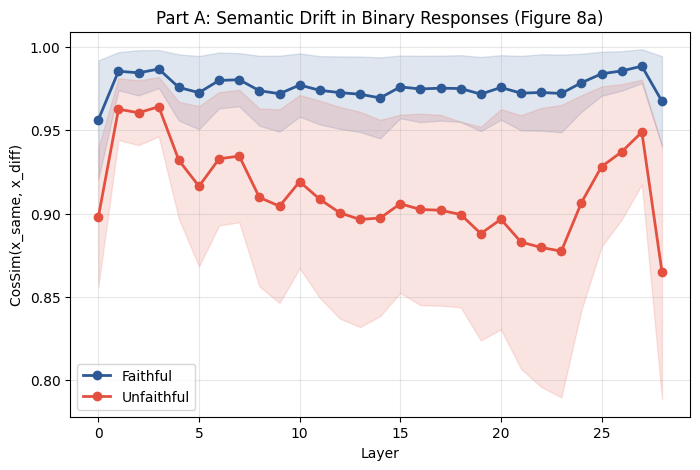

In [13]:
import numpy as np
import matplotlib.pyplot as plt


def plot_semantic_drift(faithful_curves, unfaithful_curves, num_layers, save_path=None):
    """Plots the layer-wise CosSim(x^same_l, x^diff_l) curve averaged over the faithful and
    unfaithful subsets, with a +/- std band (reproduction of Figure 8a).
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    for curves, label, color in [
        (faithful_curves, "Faithful", "#2D5A96"),
        (unfaithful_curves, "Unfaithful", "#e4503f"),
    ]:
        if not curves:
            continue
        arr = np.array(curves)  # [num_samples, num_layers]
        mean = arr.mean(axis=0)
        std = arr.std(axis=0)
        layers = np.arange(len(mean))
        ax.plot(layers, mean, "o-", label=label, color=color, linewidth=2)
        ax.fill_between(layers, mean - std, mean + std, color=color, alpha=0.15)

    ax.set_xlabel("Layer")
    ax.set_ylabel("CosSim(x_same, x_diff)")
    ax.set_title("Part A: Semantic Drift in Binary Responses (Figure 8a)")
    ax.legend()
    ax.grid(alpha=0.3)

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Сохранено: {save_path}")
    plt.show()


plot_semantic_drift(faithful_curves, unfaithful_curves, NUM_LAYERS)

## 5. Часть B — Sublayer Contribution Analysis (Figure 8b)

Здесь не нужна генерация — достаточно одного forward-прохода модели по (изображению, вопросу),
но нужно "заглянуть внутрь" каждого слоя трансформера и достать промежуточные состояния residual
stream: вход в слой $x_l$, состояние после MHA-под-слоя $x_{l+1/2}$ и финальный выход слоя (после
FFN) $x_{l+1}$ — см. формулы (1)-(2) в начале ноутбука. Это делается через forward hooks PyTorch,
без изменения кода модели.

In [16]:
# class SublayerHookRecorder:
#     """Uses PyTorch forward hooks to intercept the three residual-stream states of every
#     decoder layer during a single forward pass:

#       xl        -- input to layer l (before MHA), captured by a pre-forward hook on the
#                    whole decoder block;
#       xl_half   -- x_l + MHA(LN(x_l)), captured by a forward hook on self_attn (the residual
#                    is added manually: the saved xl plus self_attn's output);
#       xl_plus1  -- x_{l+1/2} + FFN(LN(x_{l+1/2})), captured by a forward hook on the block
#                    itself (this is exactly its final output).

#     This is the only data source needed for the Sublayer Contribution Analysis
#     (Figure 8b): given xl, xl_half and xl_plus1 you can compute the MHA contribution
#     (xl -> xl_half) and the FFN contribution (xl_half -> xl_plus1) separately.
#     """

#     def __init__(self, model, num_layers: int):
#         self.layers = model.model.layers
#         self.num_layers = num_layers
#         self.state = {}
#         self.hooks = []

#     def reset(self):
#         """Clears the buffer before processing a new sample (state from the previous
#         sample must not leak into the next one)."""
#         self.state = {i: {} for i in range(self.num_layers)}

#     def attach(self):
#         """Registers all hooks. Call this once, right after loading the model."""
#         for layer_idx in range(self.num_layers):
#             layer = self.layers[layer_idx]

#             def make_input_hook(idx):
#                 def hook(module, input):
#                     self.state[idx]["xl"] = input[0].detach()
#                 return hook

#             def make_attn_hook(idx):
#                 def hook(module, input, output):
#                     attn_output = output[0]
#                     self.state[idx]["xl_half"] = (self.state[idx]["xl"] + attn_output).detach()
#                 return hook

#             def make_output_hook(idx):
#                 def hook(module, input, output):
#                     self.state[idx]["xl_plus1"] = output[0].detach()
#                 return hook

#             self.hooks.append(layer.register_forward_pre_hook(make_input_hook(layer_idx)))
#             self.hooks.append(layer.self_attn.register_forward_hook(make_attn_hook(layer_idx)))
#             self.hooks.append(layer.register_forward_hook(make_output_hook(layer_idx)))

#     def sublayer_cosine_similarities(self):
#         """Returns (mha_cosine, ffn_cosine) -- lists of floats of length num_layers.

#         For every layer, averages over tokens the directional (normalized) cosine
#         similarity between xl and xl_half (MHA sublayer contribution) and between xl_half
#         and xl_plus1 (FFN sublayer contribution). The closer the similarity is to 1, the
#         less the sublayer "rotates" the representation vector -- per the paper, it is
#         precisely the sharp drop in FFN similarity for unfaithful examples that indicates
#         the FFN is steering the representation toward parametric priors unrelated to the
#         image.
#         """

#         def token_mean_cosine(x1, x2):
#             x1n = x1 / (torch.norm(x1, dim=-1, keepdim=True) + 1e-6)
#             x2n = x2 / (torch.norm(x2, dim=-1, keepdim=True) + 1e-6)
#             return (x1n * x2n).sum(dim=-1).mean().item()

#         mha_cosine, ffn_cosine = [], []
#         for layer_idx in range(self.num_layers):
#             s = self.state[layer_idx]
#             if not all(k in s for k in ("xl", "xl_half", "xl_plus1")):
#                 continue
#             mha_cosine.append(token_mean_cosine(s["xl"], s["xl_half"]))
#             ffn_cosine.append(token_mean_cosine(s["xl_half"], s["xl_plus1"]))
#         return mha_cosine, ffn_cosine

In [39]:
def get_decoder_layers(model) -> torch.nn.ModuleList:
    """Locates the transformer decoder's layer stack across different transformers/Qwen2-VL
    versions. The internal module path has changed between releases -- e.g. older versions
    expose it as model.model.layers, newer ones nest the text backbone under a
    language_model submodule (model.model.language_model.layers or
    model.language_model.layers). Tries the known paths first, then falls back to scanning
    model.named_modules() for anything literally called "...layers" that is a ModuleList.
    """
    candidate_chains = [
        ("model", "layers"),
        ("model", "language_model", "layers"),
        ("language_model", "layers"),
        ("language_model", "model", "layers"),
    ]
    for chain in candidate_chains:
        obj = model
        for attr in chain:
            obj = getattr(obj, attr, None)
            if obj is None:
                break
        if isinstance(obj, torch.nn.ModuleList):
            return obj

    for name, module in model.named_modules():
        if name.endswith("layers") and isinstance(module, torch.nn.ModuleList):
            return module

    raise AttributeError(
        "Could not locate the decoder layer stack on this model -- inspect "
        "model.named_modules() and add the right attribute chain to get_decoder_layers()."
    )


class SublayerHookRecorder:
    """Uses PyTorch forward hooks to intercept the three residual-stream states of every
    decoder layer during a single forward pass:

      xl        -- input to layer l (before MHA), captured by a pre-forward hook on the
                   whole decoder block;
      xl_half   -- x_l + MHA(LN(x_l)), captured by a forward hook on self_attn (the residual
                   is added manually: the saved xl plus self_attn's output);
      xl_plus1  -- x_{l+1/2} + FFN(LN(x_{l+1/2})), captured by a forward hook on the block
                   itself (this is exactly its final output).

    This is the only data source needed for the Sublayer Contribution Analysis
    (Figure 8b): given xl, xl_half and xl_plus1 you can compute the MHA contribution
    (xl -> xl_half) and the FFN contribution (xl_half -> xl_plus1) separately.

    Note on multi-GPU (e.g. Kaggle's dual-T4 with device_map="auto"): PyTorch fires our
    pre-forward hook BEFORE accelerate's own dispatch hook moves the input onto the layer's
    assigned device, so the captured xl can briefly sit on the *previous* layer's GPU. The
    self_attn hook below re-homes it onto attn_output's device before combining them --
    without that, xl + attn_output raises "Expected all tensors to be on the same device"
    whenever a layer boundary crosses a GPU boundary.

    Note on re-running cells: `del recorder` (or just re-running the cell that creates one)
    does NOT remove hooks already registered on the model -- PyTorch hooks live on the
    module itself and stay there forever until their handle's .remove() is called, `del`
    on the Python object that created them does nothing. If you re-run this class
    definition after an earlier .attach() call, the OLD hook closures are still attached
    and keep firing (first, since hooks run in registration order), so the old bug (or a
    duplicate of the new one) keeps showing up no matter how many times you redefine the
    class or recreate the object. attach() below is therefore defensive: it always clears
    every hook already sitting on these layers before registering its own, so it is safe
    to call repeatedly / after re-running earlier cells in any order.
    """

    def __init__(self, model, num_layers: int):
        self.layers = get_decoder_layers(model)
        self.num_layers = num_layers
        self.state = {}
        self.hooks = []

    def reset(self):
        """Clears the buffer before processing a new sample (state from the previous
        sample must not leak into the next one)."""
        self.state = {i: {} for i in range(self.num_layers)}

    def attach(self):
        """Registers all hooks. Safe to call more than once (including on a fresh instance
        after a previous one was `del`eted): first wipes any hooks already sitting on these
        layers/self_attn modules (accelerate's own device-dispatch hook lives elsewhere, as
        a replaced .forward method, not in these dicts, so this is safe), then registers a
        clean set. Call this once per session right after loading the model.
        """
        for layer in self.layers:
            layer._forward_pre_hooks.clear()
            layer._forward_hooks.clear()
            layer.self_attn._forward_hooks.clear()
        self.hooks = []

        for layer_idx in range(self.num_layers):
            layer = self.layers[layer_idx]

            def make_input_hook(idx):
                def hook(module, input):
                    self.state[idx]["xl"] = input[0].detach()
                return hook

            def make_attn_hook(idx):
                def hook(module, input, output):
                    attn_output = output[0]
                    # re-home xl onto attn_output's device (see class docstring: needed for
                    # multi-GPU device_map="auto" sessions, e.g. Kaggle's dual-T4)
                    residual = self.state[idx]["xl"].to(attn_output.device)
                    self.state[idx]["xl"] = residual
                    self.state[idx]["xl_half"] = (residual + attn_output).detach()
                return hook

            def make_output_hook(idx):
                def hook(module, input, output):
                    self.state[idx]["xl_plus1"] = output[0].detach()
                return hook

            self.hooks.append(layer.register_forward_pre_hook(make_input_hook(layer_idx)))
            self.hooks.append(layer.self_attn.register_forward_hook(make_attn_hook(layer_idx)))
            self.hooks.append(layer.register_forward_hook(make_output_hook(layer_idx)))

    def sublayer_cosine_similarities(self):
        """Returns (mha_cosine, ffn_cosine) -- lists of floats of length num_layers.

        For every layer, averages over tokens the directional (normalized) cosine
        similarity between xl and xl_half (MHA sublayer contribution) and between xl_half
        and xl_plus1 (FFN sublayer contribution). The closer the similarity is to 1, the
        less the sublayer "rotates" the representation vector -- per the paper, it is
        precisely the sharp drop in FFN similarity for unfaithful examples that indicates
        the FFN is steering the representation toward parametric priors unrelated to the
        image.
        """

        def token_mean_cosine(x1, x2):
            x2 = x2.to(x1.device)
            x1n = x1 / (torch.norm(x1, dim=-1, keepdim=True) + 1e-6)
            x2n = x2 / (torch.norm(x2, dim=-1, keepdim=True) + 1e-6)
            return (x1n * x2n).sum(dim=-1).mean().item()

        mha_cosine, ffn_cosine = [], []
        for layer_idx in range(self.num_layers):
            s = self.state[layer_idx]
            if not all(k in s for k in ("xl", "xl_half", "xl_plus1")):
                continue
            mha_cosine.append(token_mean_cosine(s["xl"], s["xl_half"]))
            ffn_cosine.append(token_mean_cosine(s["xl_half"], s["xl_plus1"]))
        return mha_cosine, ffn_cosine

In [40]:
recorder = SublayerHookRecorder(model, NUM_LAYERS)
recorder.attach()


def run_sublayer_contribution_experiment(model, processor, recorder, samples, device):
    """Part B end to end: for every sample, runs a single forward pass over
    (image, QUESTION_SAME) with SublayerHookRecorder attached and computes per-layer
    cos(xl, xl_half) and cos(xl_half, xl_plus1). The curves are split into faithful /
    unfaithful groups by is_faithful -- this is the data behind Figure 8b.

    Returns (faithful_mha, faithful_ffn, unfaithful_mha, unfaithful_ffn).
    """
    faithful_mha, faithful_ffn = [], []
    unfaithful_mha, unfaithful_ffn = [], []

    for sample in tqdm(samples, desc="Part B: sublayer contribution"):
        inputs = build_model_inputs(processor, sample["image_path"], QUESTION_SAME, device)

        recorder.reset()
        with torch.no_grad():
            model(**inputs)

        mha_cos, ffn_cos = recorder.sublayer_cosine_similarities()

        target_mha, target_ffn = (
            (faithful_mha, faithful_ffn) if sample["is_faithful"] == 1
            else (unfaithful_mha, unfaithful_ffn)
        )
        target_mha.append(mha_cos)
        target_ffn.append(ffn_cos)

    return faithful_mha, faithful_ffn, unfaithful_mha, unfaithful_ffn


faithful_mha, faithful_ffn, unfaithful_mha, unfaithful_ffn = run_sublayer_contribution_experiment(
    model, processor, recorder, samples, DEVICE
)
print(f"faithful: {len(faithful_mha)} примеров, unfaithful: {len(unfaithful_mha)} примеров")

Part B: sublayer contribution:   0%|          | 0/20 [00:00<?, ?it/s]

faithful: 6 примеров, unfaithful: 14 примеров


### 5.1 Визуализация (Figure 8b)

Два подграфика: слева — сходство вход/выход MHA-под-слоя по слоям, справа — то же для FFN.
По статье левый график должен быть похож для faithful/unfaithful (MHA стабилен), а правый —
показывать заметный разрыв между группами (FFN — точка расхождения).

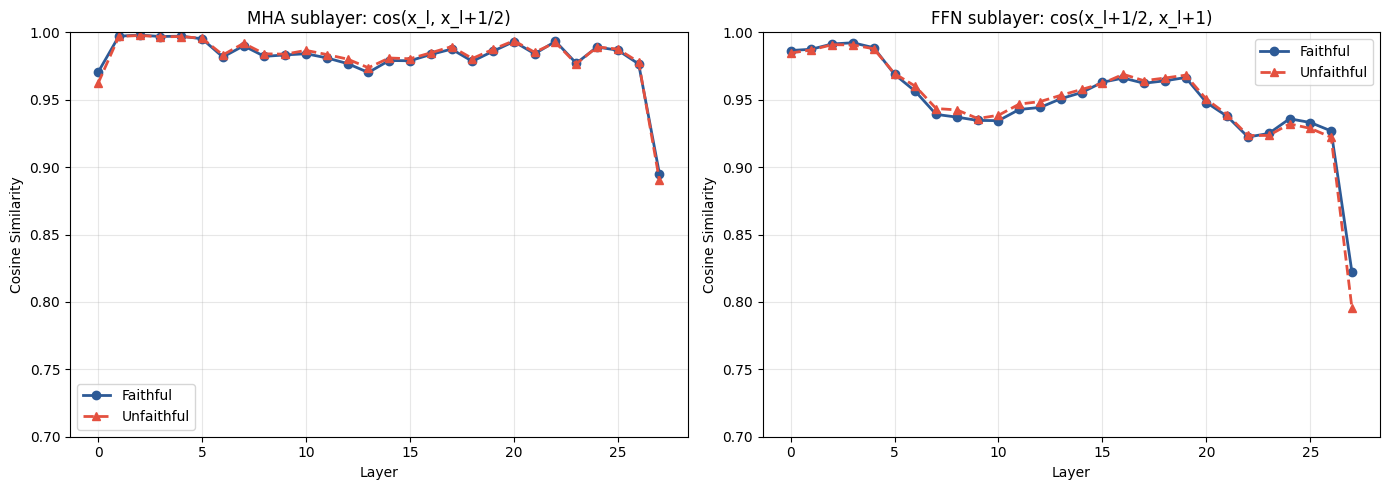

In [41]:
def plot_sublayer_contribution(faithful_mha, faithful_ffn, unfaithful_mha, unfaithful_ffn,
                                save_path=None):
    """Plots two layer-wise charts, cos(xl, xl_half) [MHA] and cos(xl_half, xl_plus1) [FFN],
    averaged over the faithful/unfaithful subsets (reproduction of Figure 8b).
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    def plot_one(ax, faithful_data, unfaithful_data, title):
        for data, label, color in [
            (faithful_data, "Faithful", "#2D5A96"),
            (unfaithful_data, "Unfaithful", "#e4503f"),
        ]:
            if not data:
                continue
            arr = np.array(data)
            mean = arr.mean(axis=0)
            layers = np.arange(len(mean))
            ax.plot(layers, mean, "o-" if label == "Faithful" else "^--",
                    label=label, color=color, linewidth=2)
        ax.set_xlabel("Layer")
        ax.set_ylabel("Cosine Similarity")
        ax.set_title(title)
        ax.legend()
        ax.grid(alpha=0.3)
        ax.set_ylim([0.7, 1.0])

    plot_one(axes[0], faithful_mha, unfaithful_mha, "MHA sublayer: cos(x_l, x_l+1/2)")
    plot_one(axes[1], faithful_ffn, unfaithful_ffn, "FFN sublayer: cos(x_l+1/2, x_l+1)")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Сохранено: {save_path}")
    plt.show()


plot_sublayer_contribution(faithful_mha, faithful_ffn, unfaithful_mha, unfaithful_ffn)

## 6. Сохранение результатов

Сырые кривые (без усреднения) сохраняются в JSON, чтобы можно было пересчитать графики или
сравнить несколько запусков/моделей без повторной прогонки модели.

In [42]:
os.makedirs(RESULTS_DIR, exist_ok=True)

with open(RESULTS_PATH, "w", encoding="utf-8") as f:
    json.dump({
        "model_path": MODEL_PATH,
        "num_layers": NUM_LAYERS,
        "part_a_semantic_drift": {
            "faithful": faithful_curves,
            "unfaithful": unfaithful_curves,
        },
        "part_b_sublayer_contribution": {
            "faithful_mha": faithful_mha,
            "faithful_ffn": faithful_ffn,
            "unfaithful_mha": unfaithful_mha,
            "unfaithful_ffn": unfaithful_ffn,
        },
    }, f, ensure_ascii=False, indent=2)

print(f"Результаты сохранены: {RESULTS_PATH}")
if IS_KAGGLE:
    print("На Kaggle всё под /kaggle/working сохраняется как Output ноутбука после Save Version.")

Результаты сохранены: /kaggle/working/results/section_4_3_results.json
На Kaggle всё под /kaggle/working сохраняется как Output ноутбука после Save Version.
